# RSV-A + Ebola truth benchmark, combined

Combines the box-plot distribution figure ("Distribution instead of medians") from
`simulated_rsva_runs/Fig_truth_metrics.ipynb` and `simulated_ebola_runs/Fig_truth_metrics.ipynb`
into a single two-row figure: **A** is RSV-A, **B** is Ebola. Same three columns
(Precision / Recall / F1), same MAF-threshold x-axis, one shared legend at the top.

Both source `af_accuracy.tsv` tables come from the same `scripts/evaluate_vs_truth.py`,
so the metric definitions below are identical to the two source notebooks -- this
notebook just reloads both tables and re-draws the box-plot panel side by side rather
than importing anything from the other notebooks.

## Imports and constants

In [7]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle

MIN_AF = 0.001          # matches --min-af in scripts/run_experiments_bench.sh
EDGE_K = 21              # matches -k there; both already applied by evaluate_vs_truth.py
MAF_THRESHOLDS = [0.001, 0.005, 0.01, 0.015, 0.02, 0.05, 0.1]
TOOL_ORDER = ['bronko', 'lofreq', 'ivar']

RSVA_ROOT = Path('/home/Users/rdd4/bronko-test/bronko_test/simulated_rsva_runs')
EBOLA_ROOT = Path('/home/Users/rdd4/bronko-test/bronko_test/simulated_ebola_runs')
FIGURES_DIR = Path('/home/Users/rdd4/bronko-test/bronko_test/figures')

# same colours as the two source notebooks so this reads as one figure set with them
_base_palette = sns.color_palette("colorblind", n_colors=4)
TOOL_PALETTE = dict(zip(TOOL_ORDER, [_base_palette[1], _base_palette[2], _base_palette[0]]))

## Loading

Same `af_accuracy.tsv` schema in both run folders: one row per (experiment, caller,
variant), tagged TP / FP / FN, with a `maf` column giving the truth AF for a truth
variant (TP/FN) or the called AF for a false positive -- see the source notebooks for
why.

In [8]:
def load_af(run_root):
    af = pd.read_csv(run_root / 'af_accuracy.tsv', sep='\t')
    af['maf'] = af['expected_af'].where(af['status'] != 'FP', af['called_af'])
    assert af['maf'].notna().all(), f'{run_root}: a row has neither an expected nor a called AF'
    return af


af_rsva = load_af(RSVA_ROOT)
af_ebola = load_af(EBOLA_ROOT)

for name, af in (('RSV-A', af_rsva), ('Ebola', af_ebola)):
    print(f"{name}: {len(af):,} rows | {af['experiment'].nunique()} experiments | "
          f"callers: {sorted(af['caller'].unique())}")
    print(af['status'].value_counts().to_string())

RSV-A: 16,588 rows | 95 experiments | callers: ['bronko', 'ivar', 'lofreq']
status
TP    11054
FP     3724
FN     1810
Ebola: 16,633 rows | 95 experiments | callers: ['bronko', 'ivar', 'lofreq']
status
TP    9788
FP    4639
FN    2206


## Metrics

Precision / recall / F1 per tool at each MAF threshold, computed per experiment so each
experiment becomes one dot -- identical to `compute_metrics` / `metrics_by_experiment` in
the two source notebooks.

In [9]:
def compute_metrics(rows, maf_thresholds=MAF_THRESHOLDS, tool_order=TOOL_ORDER):
    """Precision / recall / F1 per tool at each MAF threshold, for one set of rows."""
    out = []
    for maf in maf_thresholds:
        keep = rows[rows['maf'] >= maf]
        counts = (keep.groupby(['caller', 'status']).size().unstack(fill_value=0)
                  .reindex(index=tool_order, columns=['TP', 'FP', 'FN'], fill_value=0))
        if int((counts['TP'] + counts['FN']).max()) == 0:
            continue
        for tool in tool_order:
            tp, fp, fn = (float(counts.loc[tool, c]) for c in ('TP', 'FP', 'FN'))
            precision = tp / (tp + fp) if (tp + fp) else 1.0
            recall = tp / (tp + fn) if (tp + fn) else np.nan
            denom = precision + recall
            f1 = 2 * precision * recall / denom if denom > 0 else 0.0
            out.append(dict(tool=tool, MAF=maf, Precision=precision, Recall=recall, F1=f1,
                            TP=int(tp), FP=int(fp), FN=int(fn),
                            n_truth=int(tp + fn), n_called=int(tp + fp)))
    return pd.DataFrame(out)


def metrics_by_experiment(af, **kw):
    """One row per (experiment, tool, MAF) -- one dot per experiment in the figure."""
    return pd.concat(
        [compute_metrics(g, **kw).assign(unit=exp) for exp, g in af.groupby('experiment')],
        ignore_index=True)


rsva_metrics = metrics_by_experiment(af_rsva)
ebola_metrics = metrics_by_experiment(af_ebola)

print(f"RSV-A:  {rsva_metrics['unit'].nunique()} experiments contributing")
print(f"Ebola:  {ebola_metrics['unit'].nunique()} experiments contributing")

RSV-A:  95 experiments contributing
Ebola:  95 experiments contributing


## The figure

Two rows sharing one 2 x 3 grid: **A** = RSV-A, **B** = Ebola. `sharex='col'` keeps the
three columns lined up between rows, both rows use the same `MAF_THRESHOLDS` order and
the same y-limits, and there is a single legend at the top instead of one per row.

In [10]:
def tool_handles(tool_order=TOOL_ORDER):
    """(handles, labels) for a tool colour key, matching the boxes."""
    return ([Rectangle((0, 0), 1, 1, facecolor=TOOL_PALETTE[t], edgecolor='k', lw=0.5)
             for t in tool_order], ['bronko', 'LoFreq', 'iVar'])


def plot_row(metrics, axes, maf_thresholds=MAF_THRESHOLDS, tool_order=TOOL_ORDER,
             show_dots=True, dot_size=2.5, dot_alpha=0.45, ylim=(0, 1.18),
             show_titles=True, show_xlabel=True,
             titles=('iSNV Precision', 'iSNV Recall', 'iSNV F1')):
    """One row of box-plot Precision/Recall/F1 panels, in the style of `kind='box'` in
    the source notebooks' `plot_precision_recall_f1` (no error bars, no value labels).
    """
    metrics = metrics[metrics['MAF'].isin(maf_thresholds)].copy()
    metrics['MAF'] = pd.Categorical(metrics['MAF'], categories=maf_thresholds, ordered=True)

    for ax, metric, title in zip(axes, ('Precision', 'Recall', 'F1'), titles):
        data = metrics.dropna(subset=[metric])
        sns.boxplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                    palette=TOOL_PALETTE, ax=ax, showfliers=False, width=0.7,
                    linewidth=0.9, fliersize=0, legend=False)
        
        for patch in ax.patches:
            patch.set_alpha(0.7)
            patch.set_edgecolor('0.15')
            patch.set_linewidth(0.8)

    
        if show_dots:
            # one dot per experiment, kept faint so it reads as texture over the box
            sns.stripplot(data=data, x='MAF', y=metric, hue='tool', hue_order=tool_order,
                          dodge=True, jitter=0.12, size=dot_size, alpha=dot_alpha,
                          linewidth=0, palette=TOOL_PALETTE,
                          ax=ax, legend=False)
        ax.set_title(title if show_titles else '')
        ax.set_ylabel(metric)
        ax.set_xlabel('MAF Threshold' if show_xlabel else '')
        ax.set_ylim(*ylim)
        ax.set_xticks(range(len(maf_thresholds)))
        ax.set_xticklabels([f"{m*100:g}%" for m in maf_thresholds])
    return metrics

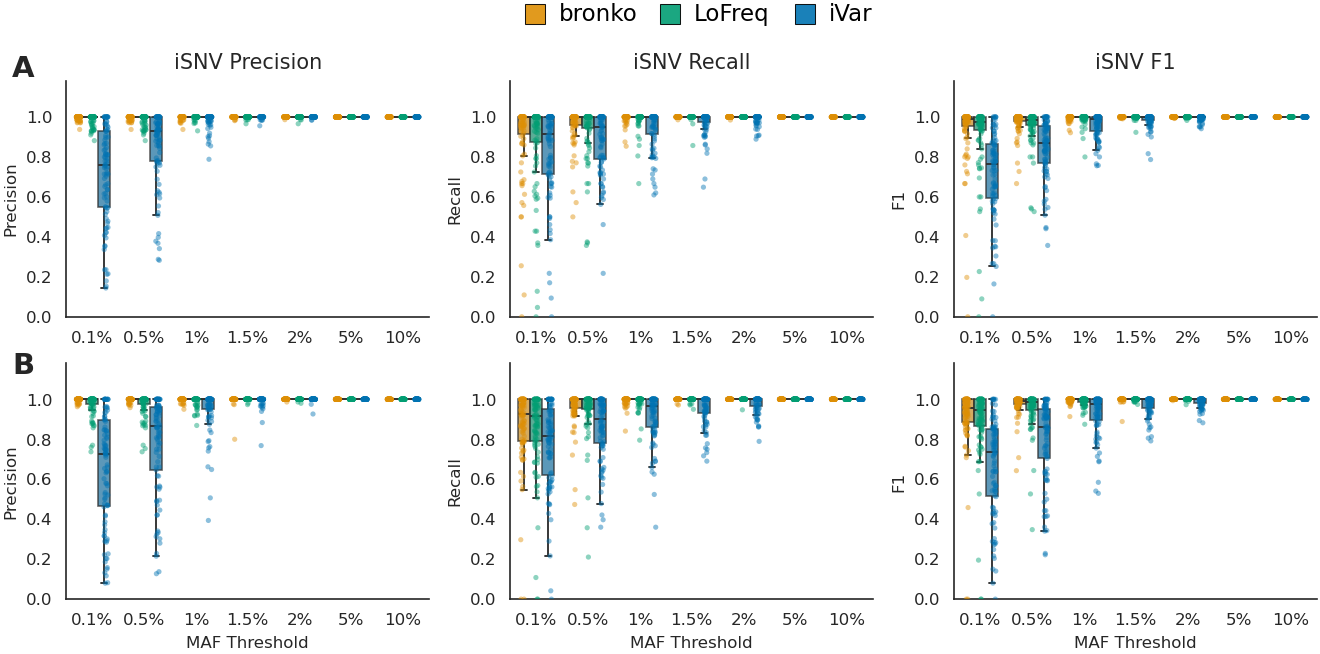

In [11]:
sns.set_theme(style="white")

# style block first: axes.spines.* and the figure-level keys are read when the figure and
# its axes are created, so setting them after plt.subplots() leaves the spines untouched
mpl.rcParams.update({
    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

    # Editable fonts in PDF/PS
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",

    # Font sizes (8-10 pt)
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    # Axes
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Lines
    "lines.linewidth": 1.5,
    "lines.markersize": 5,

    # Save figures
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    # Figure defaults
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

fig, axes = plt.subplots(2, 3, figsize=(9, 4.5))

plot_row(rsva_metrics, axes[0], show_titles=True, show_xlabel=False)
plot_row(ebola_metrics, axes[1], show_titles=False, show_xlabel=True)

fig.tight_layout(rect=(0, 0, 1, 0.94))

# swatch + label legend row, same construction as the tool key in Fig2_expanded.ipynb
# (colored Rectangle patches in figure coords, paired with fig.text labels) rather than
# a matplotlib legend box
labels = ["bronko", "LoFreq", "iVar"]
legend_colors = [TOOL_PALETTE[t] for t in TOOL_ORDER]

y = 0.97            # vertical position in figure coords
x_start = 0.40       # where first label starts
box_w, box_h = 0.015, 0.03
x_step = 0.1

for i, (label, color) in enumerate(zip(labels, legend_colors)):
    x = x_start + i * x_step
    fig.patches.append(Rectangle(
        (x, y - box_h / 2), box_w, box_h, transform=fig.transFigure,
        facecolor=color, edgecolor='black', lw=0.5, alpha=0.9))
    fig.text(x + box_w + 0.01, y, label, ha='left', va='center',
             fontsize=11, color='black')

# panel letters in absolute figure coords, same construction as Fig2_expanded.ipynb
fig.text(0.02, 0.91, 'A', fontsize=14, fontweight='bold', ha='left', va='top')
fig.text(0.02, 0.47, 'B', fontsize=14, fontweight='bold', ha='left', va='top')

for ext in ('png', 'pdf', 'svg'):
    fig.savefig(FIGURES_DIR / f'FigRSVA_Ebola_truth_boxplot.{ext}', bbox_inches='tight',
                dpi=600, facecolor='white')
plt.show()

## Strand bias vs truth status

For every *called* variant in both benchmarks, on bronko's own metric scale, split by
whether the truth table calls it a true or a false positive.

Two things shape how this is built:

* **All three callers are put on one axis.** SOR / STR_BAL / REF_BAL / ALT_BAL are
  bronko INFO fields, so lofreq and ivar do not report them. But all three do report the
  four strand counts -- lofreq as `DP4`, ivar as `REF_DP/REF_RV/ALT_DP/ALT_RV` -- so the
  metrics are recomputed from those counts with bronko's own formulas
  (`src/call.rs:1434` `strand_balance`, `:1861` `strand_odds_ratio`). Recomputing
  bronko's own calls this way reproduces its emitted values exactly, so the three callers
  are directly comparable rather than approximately so. This matters because bronko has
  almost no false positives here (11 in Ebola, 15 in RSV-A) -- nearly all of the FPs worth
  characterising belong to ivar.
* **FN variants carry no metrics and get their own panel.** bronko writes only `PASS`
  records, so a missed variant is simply absent from the VCF -- there is no SOR or
  STR_BAL for it to have. Plotting FN on those axes would silently show an empty series,
  so missed variants are plotted only on axes they genuinely have: genome position and
  truth AF.

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd

STATUS_COLORS = {'TP': '#4C9F70', 'FP': '#C4453C'}
CALLER_COLORS = dict(zip(TOOL_ORDER, [_base_palette[1], _base_palette[2], _base_palette[0]]))
CALLER_LABEL = {'bronko': 'bronko', 'lofreq': 'LoFreq', 'ivar': 'iVar'}


def strand_metrics(rf, rr, af, ar):
    """bronko's own formulas, applied to every caller so all three share one axis.

    src/call.rs:1861 strand_odds_ratio and :1434 strand_balance. The +1 on each count is
    bronko's pseudocount, kept here so recomputed values match its emitted ones exactly.
    """
    a, b, c, d = rf + 1.0, rr + 1.0, af + 1.0, ar + 1.0
    r = (a * d) / (b * c)
    return pd.DataFrame({
        'SOR': np.log(r + 1.0 / r) + np.log(np.minimum(a, b) / np.maximum(a, b))
                                   - np.log(np.minimum(c, d) / np.maximum(c, d)),
        'STR_BAL': np.minimum(a + c, b + d) / (a + b + c + d),
        'REF_BAL': np.minimum(a, b) / (a + b),
        'ALT_BAL': np.minimum(c, d) / (c + d),
    })


def read_vcf(path):
    """bronko and lofreq: strand counts from the DP4 INFO field."""
    rows = []
    with open(path) as fh:
        for line in fh:
            if line.startswith('#'):
                continue
            f = line.rstrip('\n').split('\t')
            info = dict(kv.split('=', 1) for kv in f[7].split(';') if '=' in kv)
            if 'DP4' not in info:
                continue
            rf, rr, af, ar = (float(x) for x in info['DP4'].split(','))
            rows.append((int(f[1]), f[3], f[4], rf, rr, af, ar,
                         float(info.get('DP', np.nan)), float(info.get('AF', np.nan))))
    return pd.DataFrame(rows, columns=['pos', 'ref', 'alt', 'ref_fwd', 'ref_rev',
                                       'alt_fwd', 'alt_rev', 'DP', 'AF'])


def read_ivar(path):
    """ivar writes a TSV; REF_RV/ALT_RV are the reverse-strand halves of REF_DP/ALT_DP."""
    t = pd.read_csv(path, sep='\t')
    t = t[t['PASS'] == True]
    return pd.DataFrame({
        'pos': t['POS'].astype(int), 'ref': t['REF'], 'alt': t['ALT'],
        'ref_fwd': (t['REF_DP'] - t['REF_RV']).astype(float),
        'ref_rev': t['REF_RV'].astype(float),
        'alt_fwd': (t['ALT_DP'] - t['ALT_RV']).astype(float),
        'alt_rev': t['ALT_RV'].astype(float),
        'DP': t['TOTAL_DP'].astype(float), 'AF': t['ALT_FREQ'].astype(float),
    }).reset_index(drop=True)


CALLER_FILES = {
    'bronko': ('reads_1.vcf', read_vcf),
    'lofreq': ('reads_1_lofreq.vcf', read_vcf),
    'ivar':   ('reads_1_ivar_ivar.tsv', read_ivar),
}


def load_called(run_root, experiments):
    """Every called variant from all three callers, on bronko's metric scale.

    `experiments` comes from af_accuracy rather than from the directory listing: there
    are 100 experiment_* dirs but only 95 were evaluated, and 11/12/91/94/95 must stay out.
    """
    out = []
    for exp in experiments:
        d = run_root / f'experiment_{exp}' / 'reads_1_k21'
        for caller, (fname, reader) in CALLER_FILES.items():
            p = d / fname
            if not p.exists():
                continue
            df = reader(p)
            if df.empty:
                continue
            df = pd.concat([df.reset_index(drop=True),
                            strand_metrics(df['ref_fwd'], df['ref_rev'],
                                           df['alt_fwd'], df['alt_rev'])], axis=1)
            df['experiment'], df['caller'] = exp, caller
            out.append(df)
    return pd.concat(out, ignore_index=True)


def annotate(called, af_accuracy):
    """Attach truth status to called variants; return (called, missed)."""
    acc = af_accuracy
    called = called.merge(
        acc[['experiment', 'caller', 'pos', 'ref', 'alt', 'status', 'expected_af']],
        on=['experiment', 'caller', 'pos', 'ref', 'alt'], how='left')
    called['status'] = called['status'].fillna('unevaluated')
    called['mutation'] = called['ref'] + '>' + called['alt']
    missed = acc[acc['status'] == 'FN'].copy()
    missed['mutation'] = missed['ref'] + '>' + missed['alt']
    return called, missed


def load_organism(run_root):
    af = pd.read_csv(run_root / 'af_accuracy.tsv', sep='\t')
    called, missed = annotate(load_called(run_root, sorted(af['experiment'].unique())), af)
    # reconcile against the truth table so any silent parsing loss is visible, not assumed
    got = called[called['status'].isin(['TP', 'FP'])].groupby(['caller', 'status']).size()
    want = af[af['status'].isin(['TP', 'FP'])].groupby(['caller', 'status']).size()
    rec = pd.concat([want.rename('truth'), got.rename('matched')], axis=1).fillna(0).astype(int)
    rec['unmatched'] = rec['truth'] - rec['matched']
    return called, missed, rec


called_ebola, missed_ebola, rec_ebola = load_organism(EBOLA_ROOT)
called_rsva, missed_rsva, rec_rsva = load_organism(RSVA_ROOT)

for name, called, missed, rec in (('Ebola', called_ebola, missed_ebola, rec_ebola),
                                  ('RSV-A', called_rsva, missed_rsva, rec_rsva)):
    print(f"=== {name}: {len(called):,} called, {len(missed):,} missed (FN) ===")
    print(rec.to_string(), end='\n\n')

=== Ebola: 14,430 called, 2,206 missed (FN) ===
               truth  matched  unmatched
caller status                           
bronko FP         11        8          3
       TP       3438     3434          4
ivar   FP       4478     4478          0
       TP       2987     2987          0
lofreq FP        150      150          0
       TP       3363     3363          0

=== RSV-A: 14,784 called, 1,810 missed (FN) ===
               truth  matched  unmatched
caller status                           
bronko FP         15       13          2
       TP       3848     3846          2
ivar   FP       3627     3627          0
       TP       3451     3451          0
lofreq FP         82       82          0
       TP       3755     3755          0



In [16]:
def _scatter_by_status(ax, d, x, y, s=6, alpha=0.35):
    for st in ('TP', 'FP'):
        sub = d[d['status'] == st].dropna(subset=[x, y])
        if len(sub):
            ax.scatter(sub[x], sub[y], s=s, alpha=alpha, linewidth=0,
                       color=STATUS_COLORS[st], label=f'{st} (n={len(sub):,})')
    ax.grid(alpha=0.15, linewidth=0.5)


def fig_metrics(called, organism):
    """Metric pairs per caller, TP vs FP."""
    pairs = [('SOR', 'STR_BAL'), ('AF', 'STR_BAL'), ('AF', 'SOR'), ('REF_BAL', 'ALT_BAL')]
    fig, axes = plt.subplots(len(TOOL_ORDER), len(pairs), figsize=(13, 8.5))
    for i, caller in enumerate(TOOL_ORDER):
        d = called[called['caller'] == caller]
        for j, (x, y) in enumerate(pairs):
            ax = axes[i, j]
            _scatter_by_status(ax, d, x, y)
            ax.set_xlabel(x, fontsize=8)
            ax.set_ylabel(y if j == 0 else '', fontsize=8)
            if y in ('STR_BAL', 'REF_BAL', 'ALT_BAL'):
                ax.set_ylim(-0.02, 0.52)
            if x == 'AF':
                hi = d['AF'].max() * 1.05
                ax.set_xlim(-0.02 * hi, hi)
            if i == 0:
                ax.set_title(f'{x} vs {y}', fontsize=9)
            if j == 0:
                ax.text(-0.32, 0.5, CALLER_LABEL[caller], transform=ax.transAxes,
                        fontsize=11, fontweight='bold', rotation=90, ha='center', va='center')
            ax.legend(fontsize=6, loc='best', framealpha=0.85, markerscale=2)
    fig.suptitle(f'{organism}: strand-bias metrics by truth status (called variants)',
                 fontsize=13, fontweight='bold')
    fig.tight_layout(rect=(0.02, 0, 1, 0.96))
    return fig


def fig_genome(called, organism):
    """AF and strand balance along the genome, per caller, TP vs FP."""
    fig, axes = plt.subplots(len(TOOL_ORDER), 2, figsize=(13, 8), sharex=True)
    for i, caller in enumerate(TOOL_ORDER):
        d = called[called['caller'] == caller]
        for j, y in enumerate(['AF', 'STR_BAL']):
            ax = axes[i, j]
            _scatter_by_status(ax, d, 'pos', y, s=5, alpha=0.3)
            ax.set_ylabel(y, fontsize=8)
            if y == 'STR_BAL':
                ax.set_ylim(-0.02, 0.52)
            else:
                hi = called['AF'].max() * 1.05
                ax.set_ylim(-0.02 * hi, hi)
            if i == len(TOOL_ORDER) - 1:
                ax.set_xlabel('genome position', fontsize=9)
            if i == 0:
                ax.set_title(f'{y} across the genome', fontsize=9)
            if j == 0:
                ax.text(-0.10, 0.5, CALLER_LABEL[caller], transform=ax.transAxes,
                        fontsize=11, fontweight='bold', rotation=90, ha='center', va='center')
            ax.legend(fontsize=6, loc='upper right', framealpha=0.85, markerscale=2)
    fig.suptitle(f'{organism}: called-variant AF and strand balance across the genome',
                 fontsize=13, fontweight='bold')
    fig.tight_layout(rect=(0.02, 0, 1, 0.96))
    return fig


def fig_missed(missed, organism):
    """Missed truth variants, on the only axes they have: position and truth AF."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
    order = missed['caller'].value_counts().index.tolist()

    ax = axes[0]
    for caller in order:  # largest set first so smaller callers stay visible on top
        sub = missed[missed['caller'] == caller]
        ax.scatter(sub['pos'], sub['expected_af'], s=7, linewidth=0,
                   alpha=0.25 if caller == order[0] else 0.7,
                   color=CALLER_COLORS[caller],
                   label=f'{CALLER_LABEL[caller]} (n={len(sub):,})')
    ax.set_xlabel('genome position', fontsize=9)
    ax.set_ylabel('truth AF', fontsize=9)
    ax.set_yscale('log')
    ax.set_title('Missed truth variants (FN) across the genome', fontsize=10)
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(alpha=0.15, linewidth=0.5)

    ax = axes[1]
    bins = np.logspace(np.log10(max(missed['expected_af'].min(), 1e-4)),
                       np.log10(missed['expected_af'].max()), 40)
    for caller in TOOL_ORDER:
        sub = missed[missed['caller'] == caller]
        # step outlines, not filled bars: three overlapping fills hide each other
        ax.hist(sub['expected_af'], bins=bins, histtype='step', linewidth=1.6,
                color=CALLER_COLORS[caller],
                label=f'{CALLER_LABEL[caller]} (n={len(sub):,})')
    ax.set_xscale('log')
    ax.set_xlabel('truth AF', fontsize=9)
    ax.set_ylabel('missed count', fontsize=9)
    ax.set_title('Truth AF of missed variants', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15, linewidth=0.5, axis='y')

    fig.suptitle(f'{organism}: what each caller missed (no called metrics exist for these)',
                 fontsize=12, fontweight='bold')
    fig.tight_layout(rect=(0, 0, 1, 0.90))
    return fig

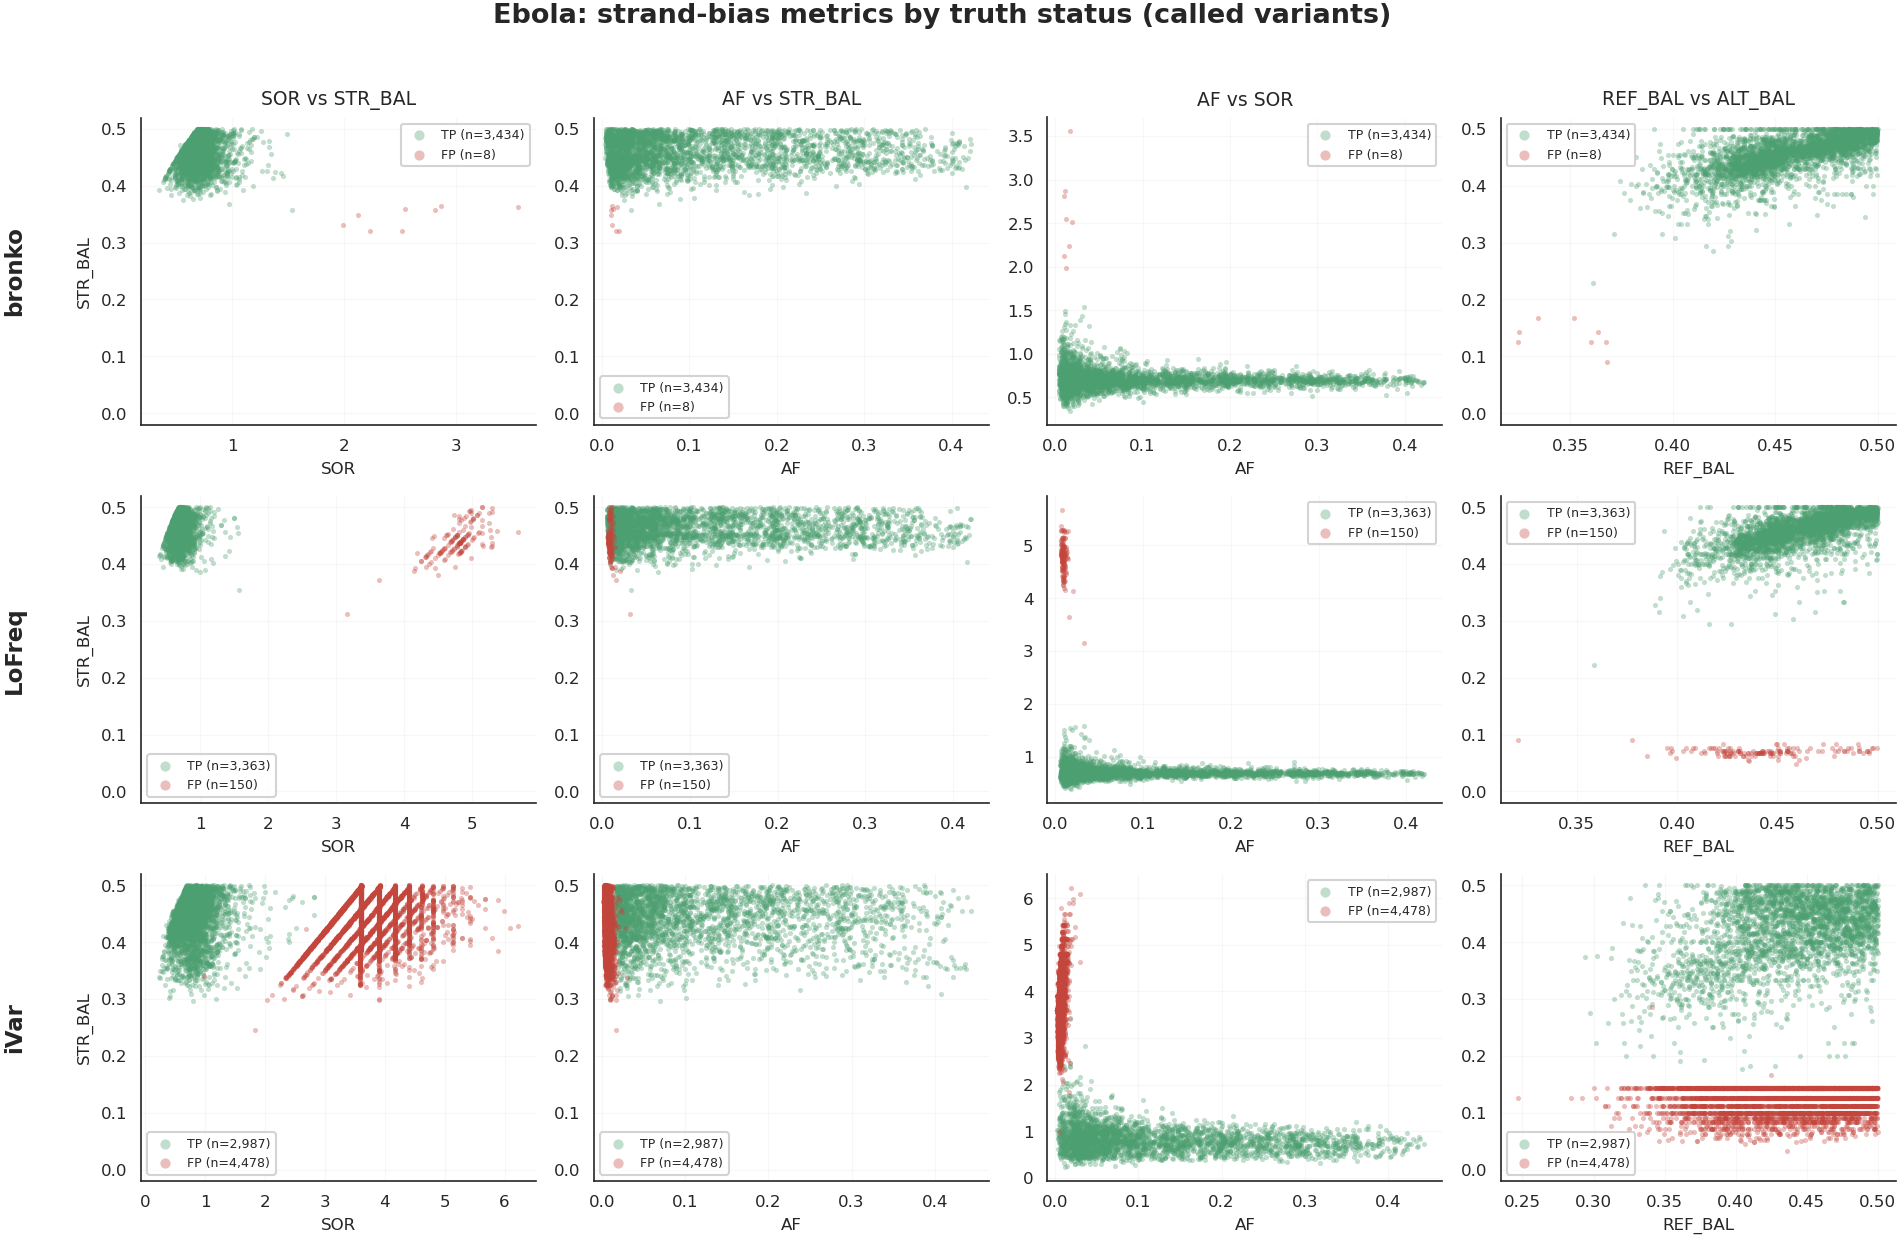

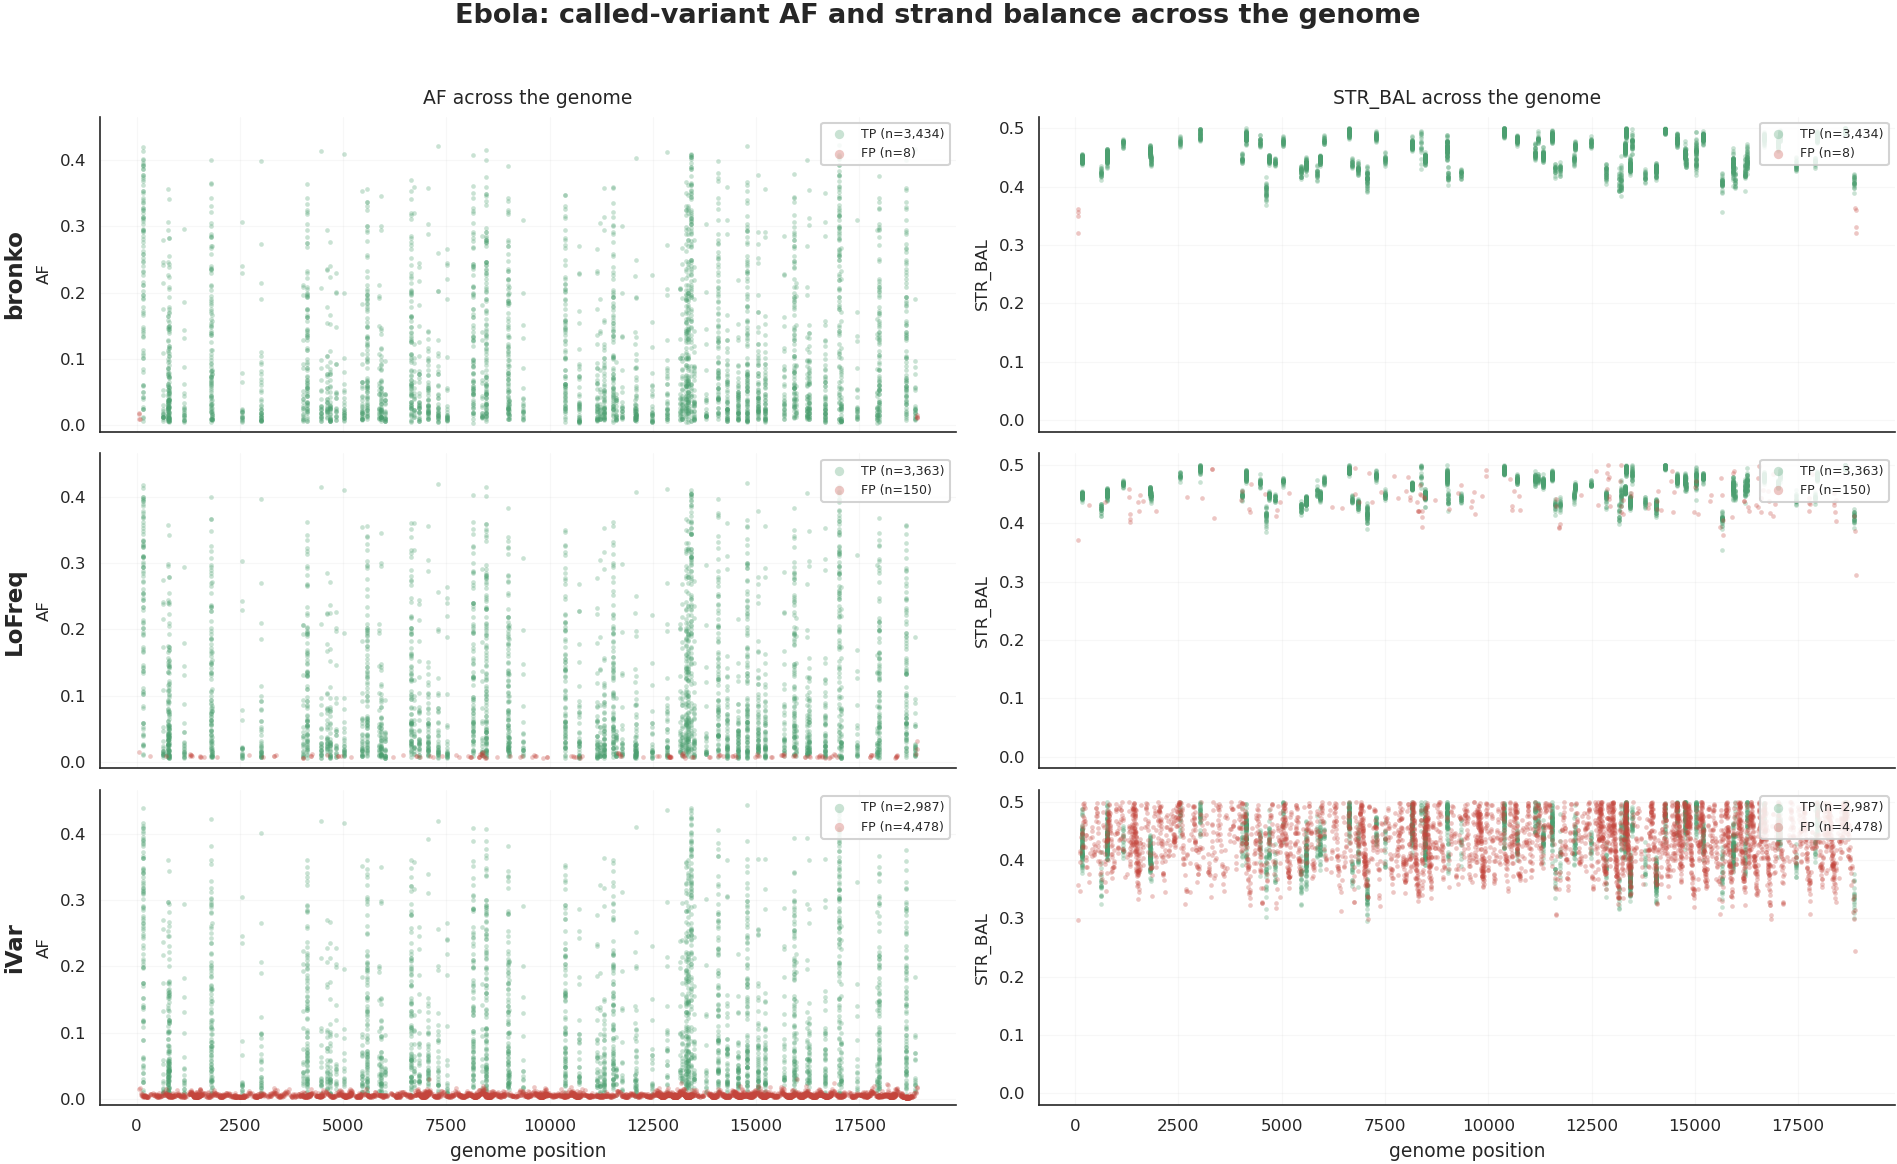

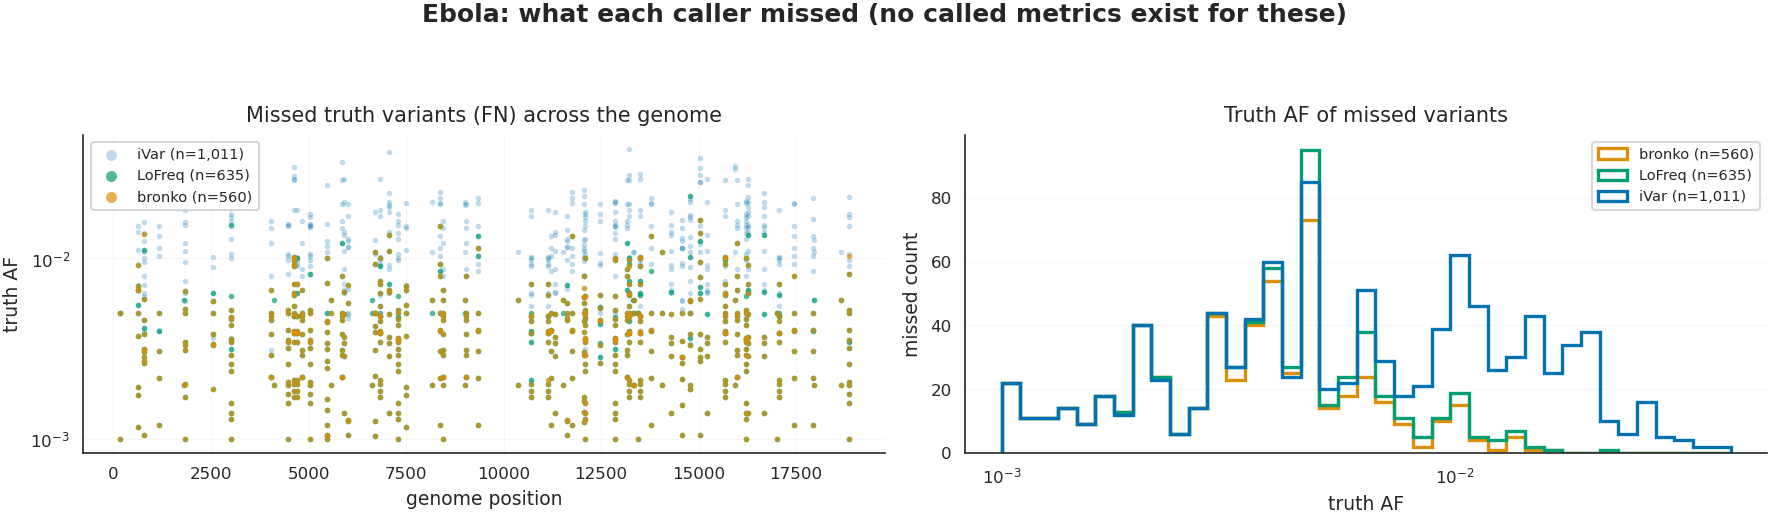

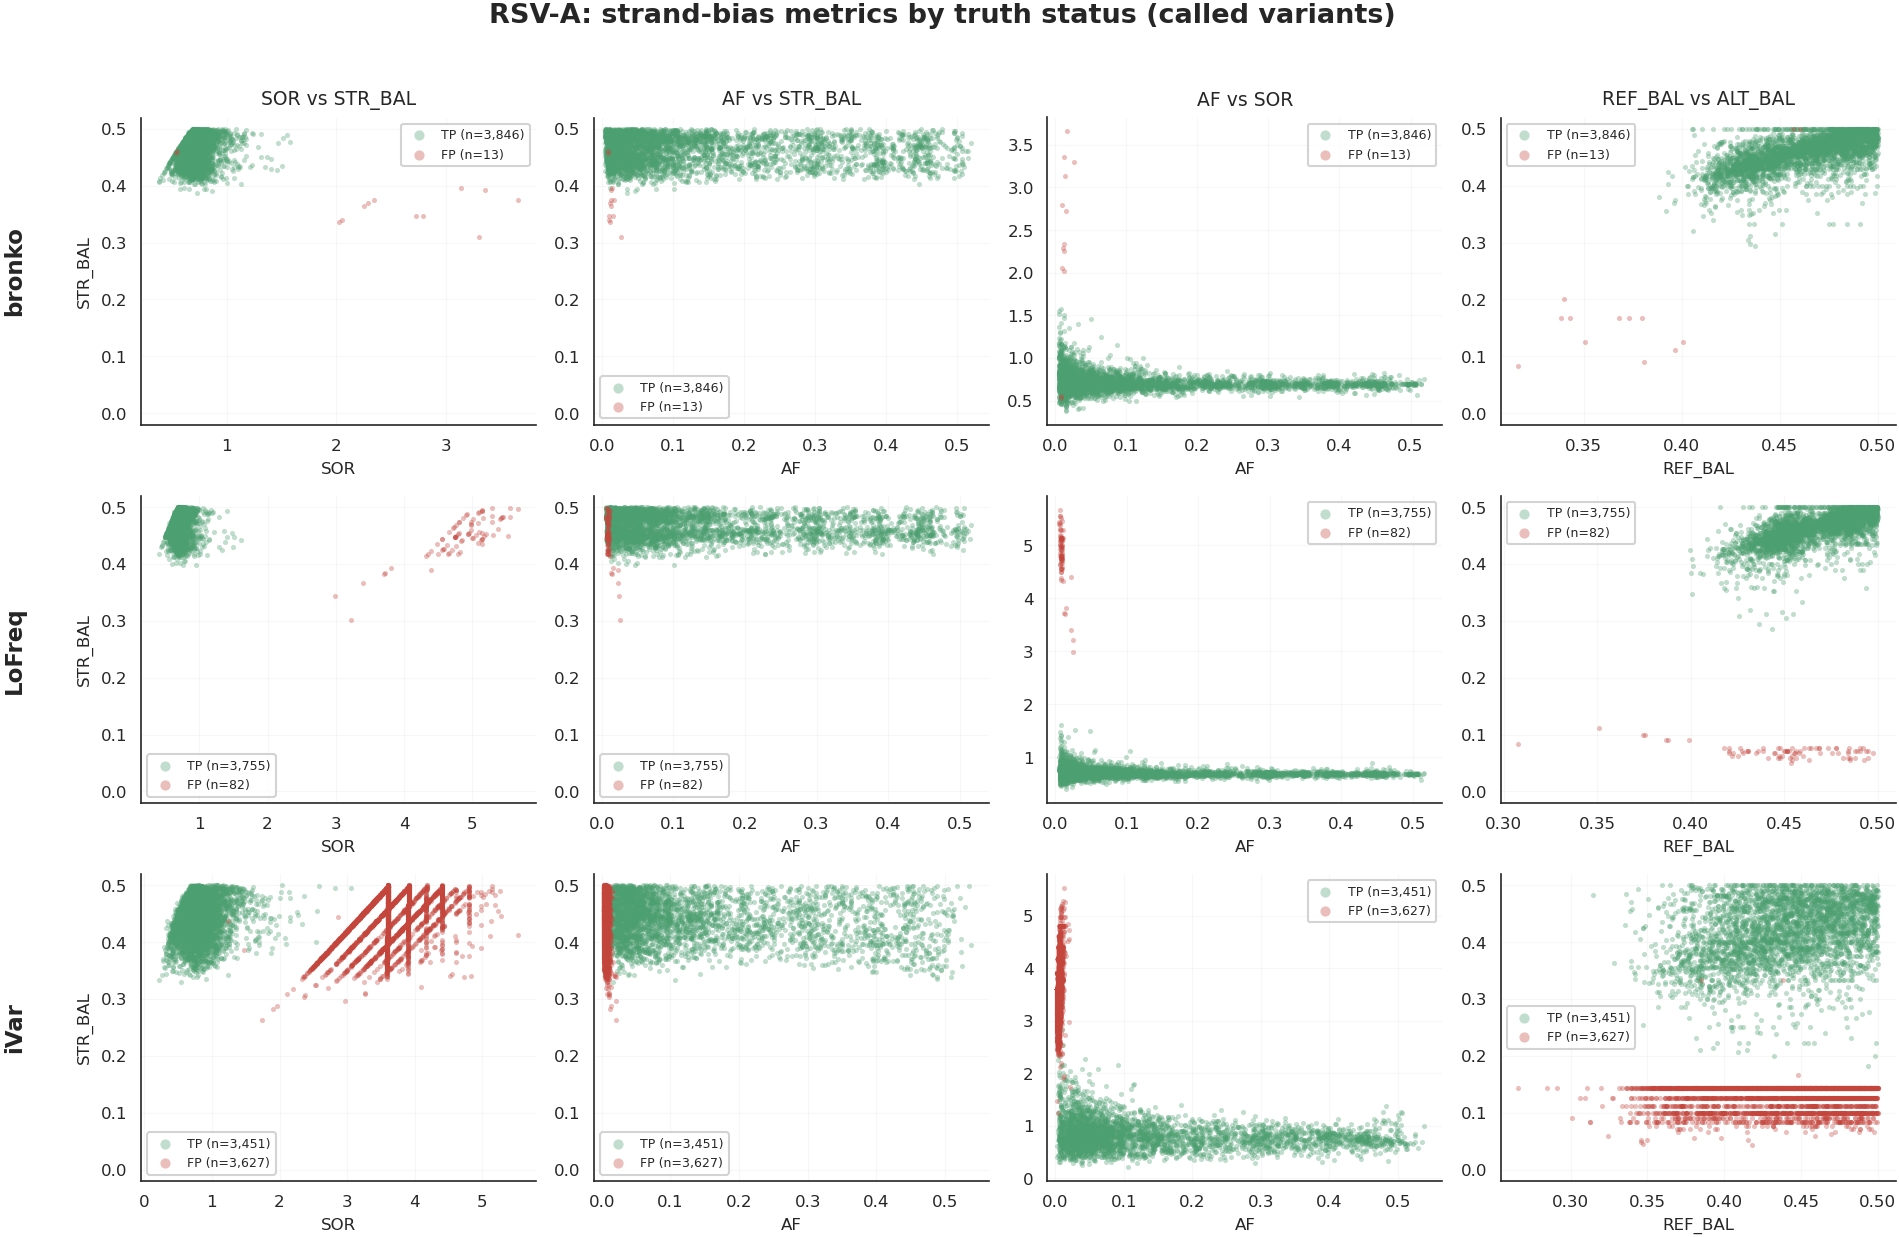

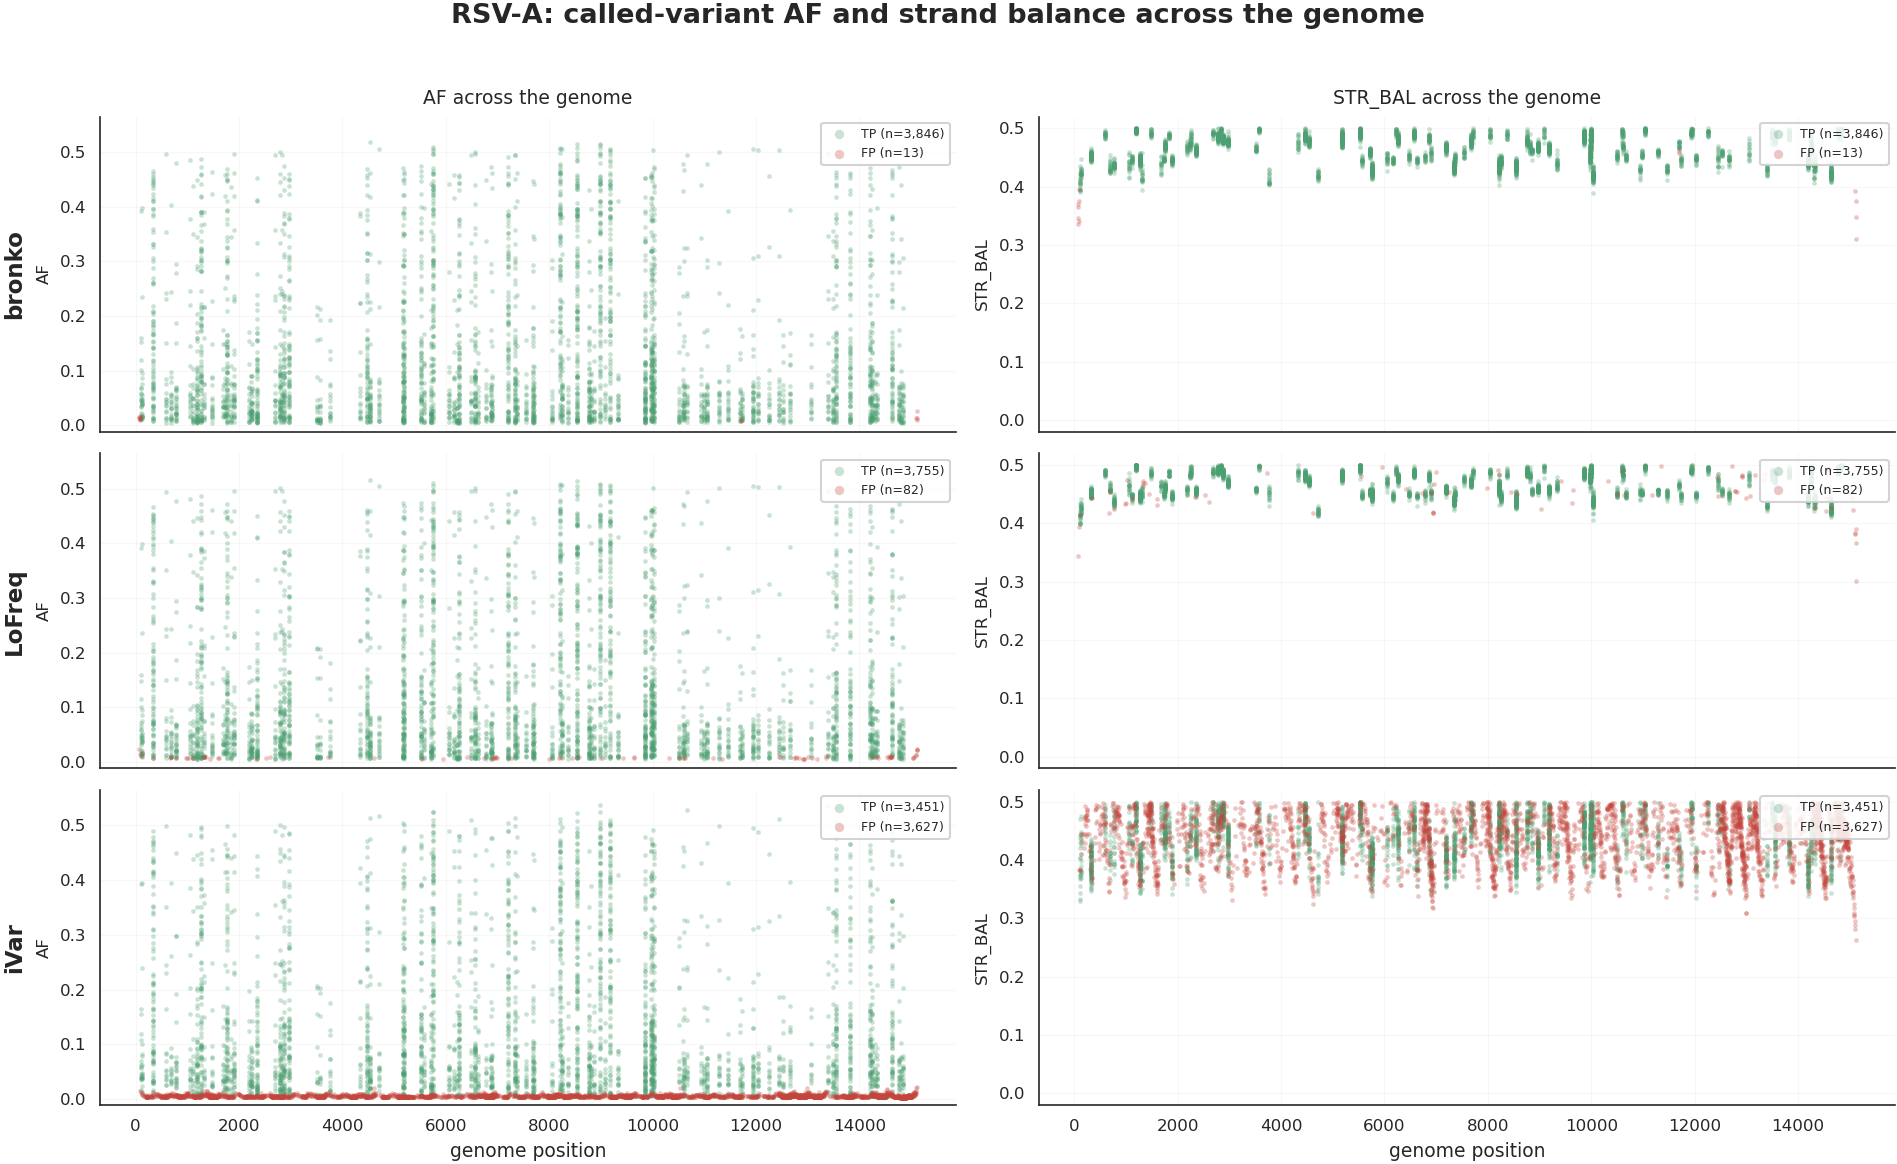

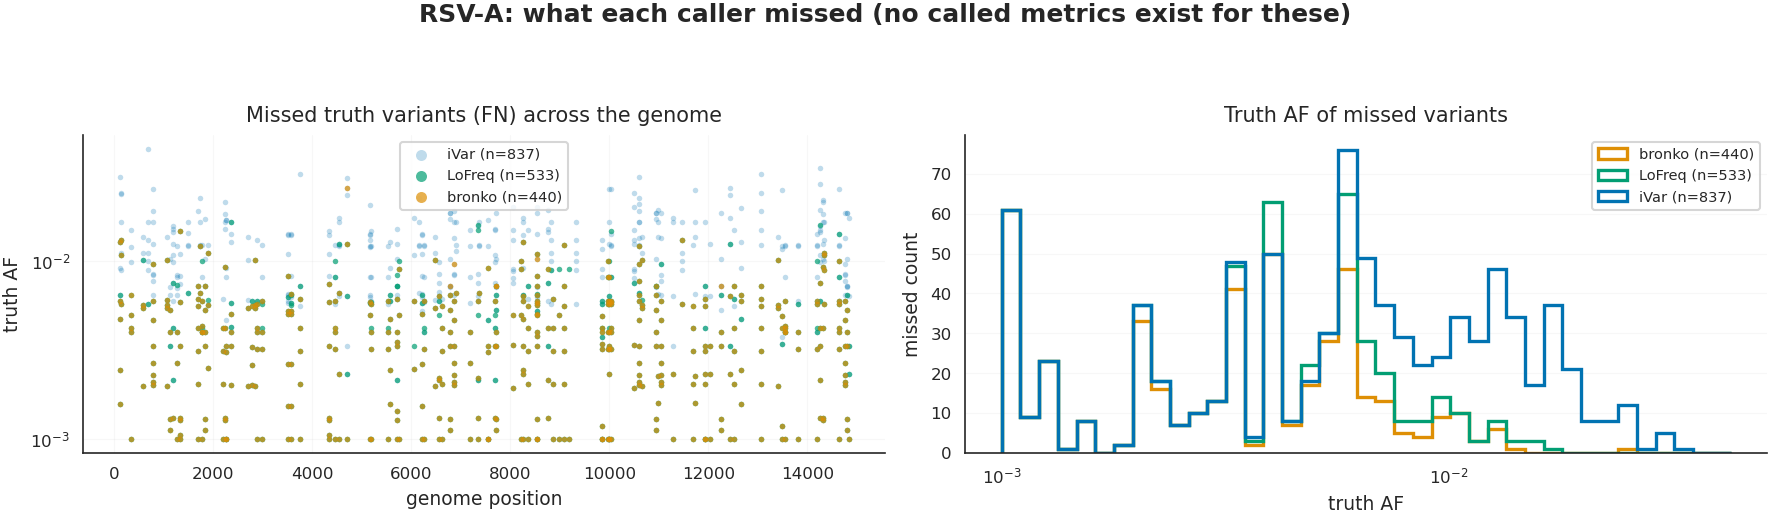

In [17]:
figs = {}
for organism, called, missed in (('Ebola', called_ebola, missed_ebola),
                                 ('RSV-A', called_rsva, missed_rsva)):
    tag = organism.lower().replace('-', '')
    figs[f'{tag}_strandbias_metrics'] = fig_metrics(called, organism)
    figs[f'{tag}_strandbias_genome'] = fig_genome(called, organism)
    figs[f'{tag}_missed_variants'] = fig_missed(missed, organism)

plt.show()

In [18]:
for name, fig in figs.items():
    for ext in ('png', 'pdf'):
        fig.savefig(FIGURES_DIR / f'{name}.{ext}', bbox_inches='tight', dpi=600,
                    facecolor='white')
    print('saved', name)

saved ebola_strandbias_metrics
saved ebola_strandbias_genome
saved ebola_missed_variants
saved rsva_strandbias_metrics
saved rsva_strandbias_genome
saved rsva_missed_variants
